In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    error = []
    
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
            
        diff = np.linalg.norm(x_new - x, ord=np.inf)
        error.append(diff)
        
        if diff < tol:
            return x_new, k, np.array(error)
        x = x_new

    return x, max_iterations, np.array(error)

Jacobi method function

In [2]:
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    error = []
    
    for k in range(max_iterations):
        x_new = x.copy()
        
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
            
        diff = np.linalg.norm(x_new - x, ord=np.inf)
        error.append(diff)
        
        if diff < tol:
            return x_new, k, np.array(error)
        x = x_new

    return x, max_iterations, np.array(error)

Gauss-sidel function

In [3]:
A = np.array([[3, -0.1, -0.2], [0.1, 7, -0.3], [0.3, -0.2, 10]], dtype=float)
b = np.array([7.85, -19.3, 71.4], dtype=float)
x0 = np.array([0, 0, 0], dtype=float)
max_iterations = 100000

solutionj3, iterationsj3, errorsj3 = jacobi(A, b, x0, 1e-3, max_iterations)
solution3, iterations3, errors3 = gauss_seidel(A, b, x0, 1e-3, max_iterations)

solutionj6, iterationsj6, errorsj6 = jacobi(A, b, x0, 1e-6, max_iterations)
solution6, iterations6, errors6 = gauss_seidel(A, b, x0, 1e-6, max_iterations)

solutionj9, iterationsj9, errorsj9 = jacobi(A, b, x0, 1e-9, max_iterations)
solution9, iterations9, errors9 = gauss_seidel(A, b, x0, 1e-9, max_iterations)

print(f"Solution Jacobi e-3: {solutionj3}")
print(f"Iterations Jacobi e-3: {iterationsj3}")
print(f"Solution Gauss part e-3: {solution3}")
print(f"Iterations Gauss part e-3: {iterations3}")

print(f"Solution Jacobi e-6: {solutionj6}")
print(f"Iterations Jacobi e-6: {iterationsj6}")
print(f"Solution Gauss part e-6: {solution6}")
print(f"Iterations Gauss part e-6: {iterations6}")

print(f"Solution Jacobi e-9: {solutionj9}")
print(f"Iterations Jacobi e-9: {iterationsj9}")
print(f"Solution Gauss part e-9: {solution9}")
print(f"Iterations Gauss part e-9: {iterations9}")


Solution Jacobi e-3: [ 3.0000225  -2.50000266  6.99998104]
Iterations Jacobi e-3: 3
Solution Gauss part e-3: [ 3.00000035 -2.50000004  6.99999999]
Iterations Gauss part e-3: 3
Solution Jacobi e-6: [ 3.  -2.5  7. ]
Iterations Jacobi e-6: 6
Solution Gauss part e-6: [ 3.  -2.5  7. ]
Iterations Gauss part e-6: 4
Solution Jacobi e-9: [ 3.  -2.5  7. ]
Iterations Jacobi e-9: 8
Solution Gauss part e-9: [ 3.  -2.5  7. ]
Iterations Gauss part e-9: 6


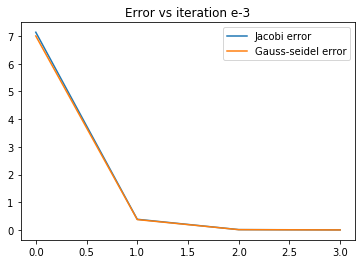

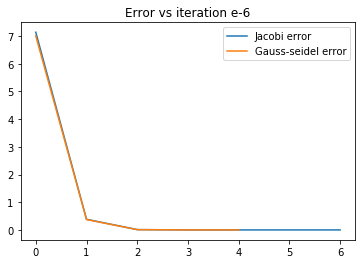

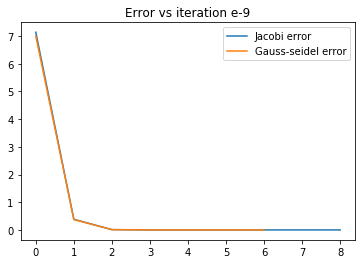

In [4]:
plt.figure()
plt.plot(errorsj3, label="Jacobi error")
plt.plot(errors3, label="Gauss-seidel error")
plt.title("Error vs iteration e-3")
plt.legend()
    
plt.figure()
plt.plot(errorsj6, label="Jacobi error")
plt.plot(errors6, label="Gauss-seidel error")
plt.title("Error vs iteration e-6")
plt.legend()

plt.figure()
plt.plot(errorsj9, label="Jacobi error")
plt.plot(errors9, label="Gauss-seidel error")
plt.title("Error vs iteration e-9")
plt.legend()
plt.show()

Gauss required less iterations to converge for all except the tol of 1e-3. As the tolerance increases, the number of iterations needed increases, going up to 8 for jacobi with a tolerance of 1e-9. 